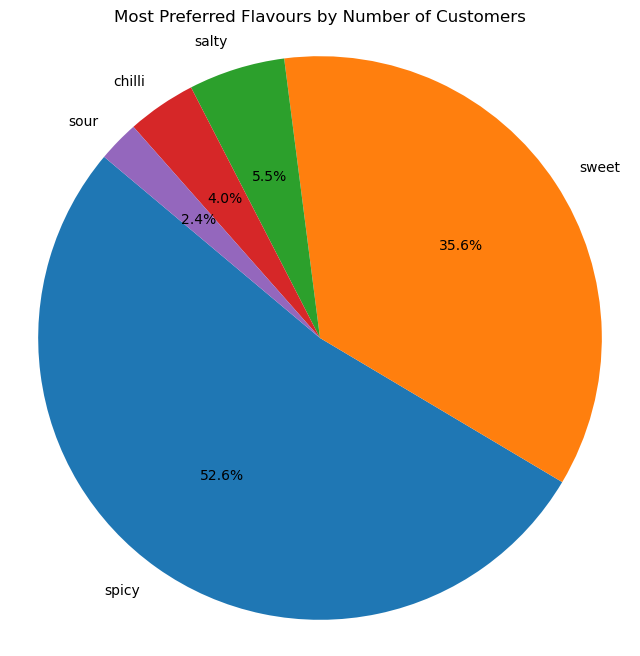

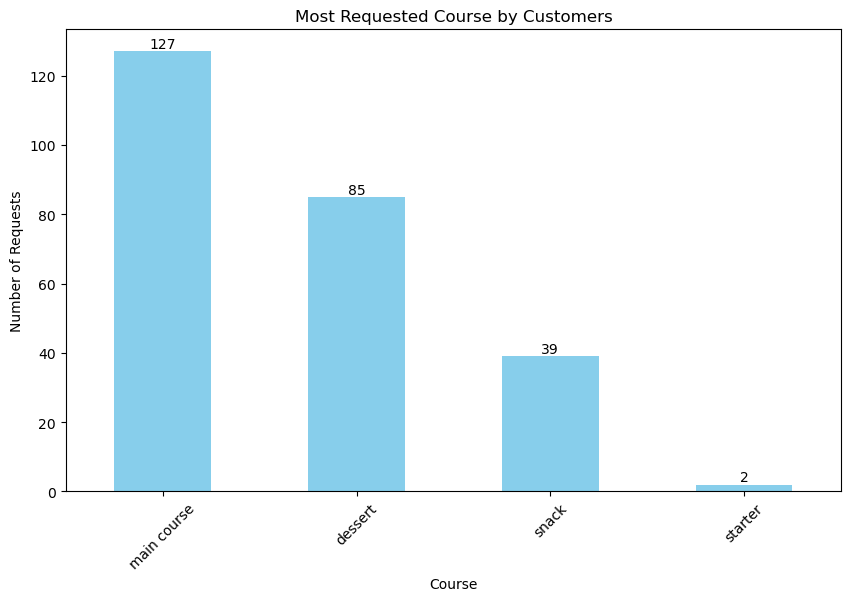

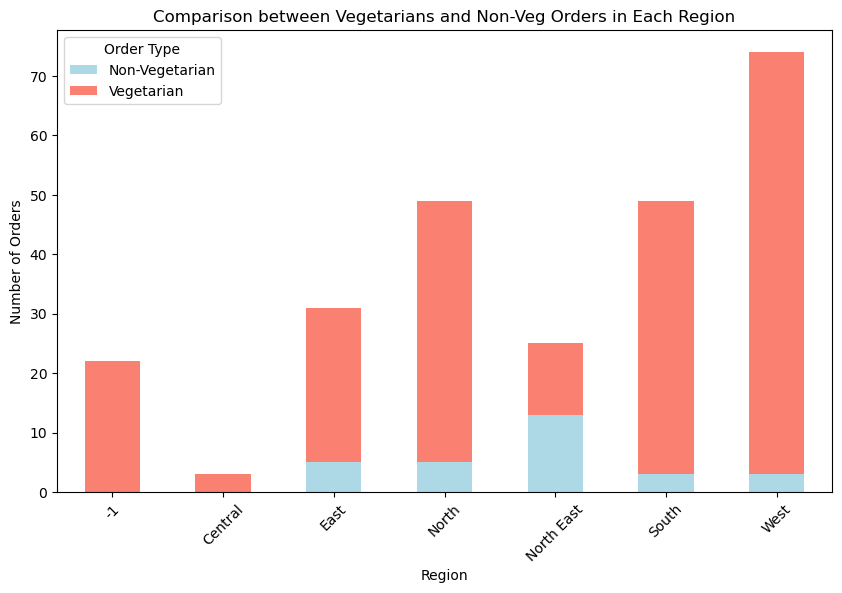

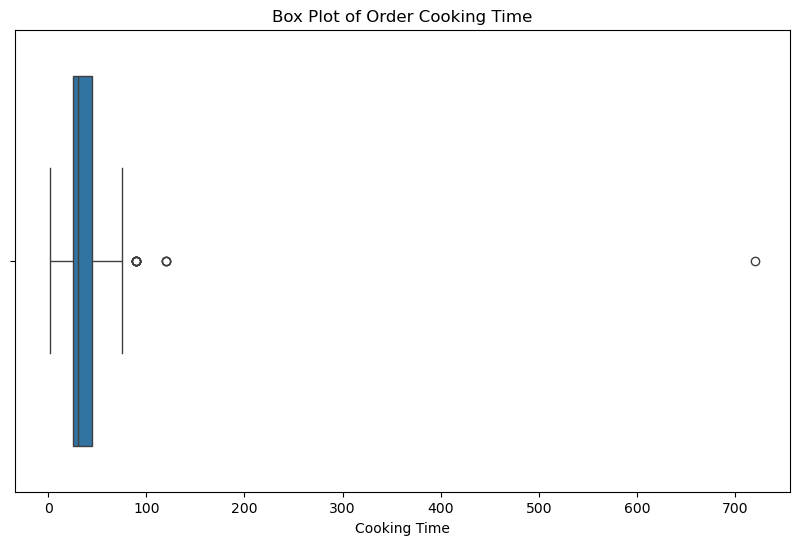

Outliers in cooking time:
            Name                                        Ingredients  \
27       Malapua         Yoghurt, refined flour, ghee, fennel seeds   
62     Shrikhand                     Curd, sugar, saffron, cardamom   
75       Biryani  Chicken thighs, basmati rice, star anise, swee...   
114  Pindi chana   Fennel, tea bags, tomato, kasuri methi, cinnamon   

               Diet  cook_time flavor_profile       course        state region  
27       vegetarian      120.0          sweet      dessert        Bihar  North  
62       vegetarian      720.0          sweet      dessert  Maharashtra   West  
75   non vegetarian      120.0          spicy  main course    Telangana  South  
114      vegetarian      120.0          spicy  main course       Punjab  North  


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Indian_food.csv')
df.columns = ['Name', 'Ingredients', 'Diet', 'cook_time', 'flavor_profile', 'course', 'state', 'region']

mode_state = df['state'].mode()[0]
df['state'] = df['state'].replace(-1, mode_state)

df.loc[df['state'] == mode_state, 'region'] = df['region'].mode()[0]

mean_cook_time = df['cook_time'].replace(-1, pd.NA).mean()
df['cook_time'] = df['cook_time'].replace(-1, mean_cook_time)

flavour_counts = df['flavor_profile'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(flavour_counts, labels=flavour_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Most Preferred Flavours by Number of Customers')
plt.axis('equal')
plt.show()

course_counts = df['course'].value_counts()
plt.figure(figsize=(10, 6))
course_counts.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Most Requested Course by Customers')
plt.xlabel('Course')
plt.ylabel('Number of Requests')

for index, value in enumerate(course_counts.sort_values(ascending=False)):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.xticks(rotation=45)
plt.show()

region_counts = df.groupby(['region', 'Diet']).size().unstack(fill_value=0)
region_counts.plot(kind='bar', stacked=True, figsize=(10, 6), color=['lightblue', 'salmon'])
plt.title('Comparison between Vegetarians and Non-Veg Orders in Each Region')
plt.xlabel('Region')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.legend(title='Order Type', labels=['Non-Vegetarian', 'Vegetarian'])
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['cook_time'])
plt.title('Box Plot of Order Cooking Time')
plt.xlabel('Cooking Time')
plt.show()

outliers = df[df['cook_time'] > (mean_cook_time + 1.5 * df['cook_time'].std())]
print("Outliers in cooking time:")
print(outliers)

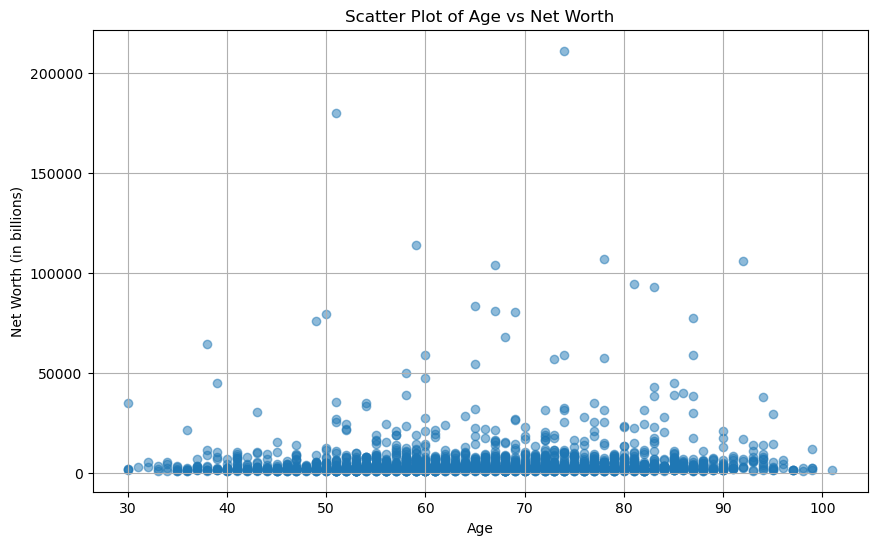

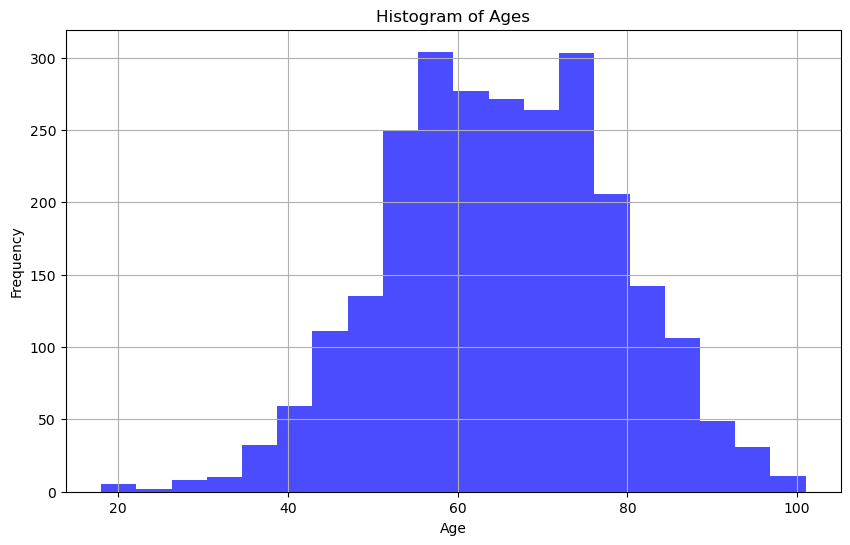

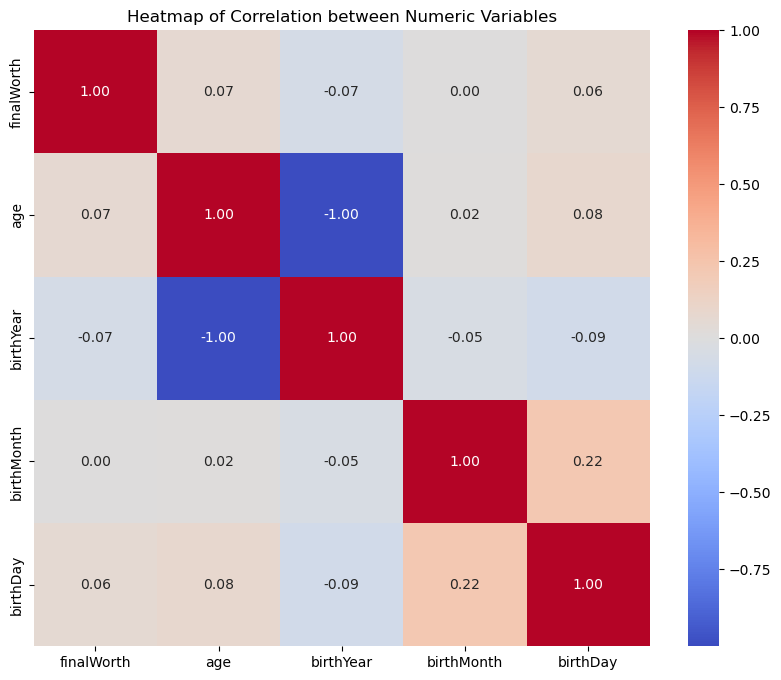

In [6]:
# already impored the libraries in the first question
df = pd.read_csv('Billionaires_Stats.csv', encoding='ISO-8859-1')  # used chatgpt here as unable to open the csv was getting the unicode error

df_age_30_plus = df[df['age'] >= 30]

plt.figure(figsize=(10, 6))
plt.scatter(df_age_30_plus['age'], df_age_30_plus['finalWorth'], alpha=0.5)
plt.title('Scatter Plot of Age vs Net Worth')
plt.xlabel('Age')
plt.ylabel('Net Worth (in billions)')
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=20, color='blue', alpha=0.7)
plt.title('Histogram of Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid()
plt.show()

numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Heatmap of Correlation between Numeric Variables')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Heatmap of Correlation between Numeric Variables')
plt.savefig('heatmap_correlation.png')  
plt.close() 

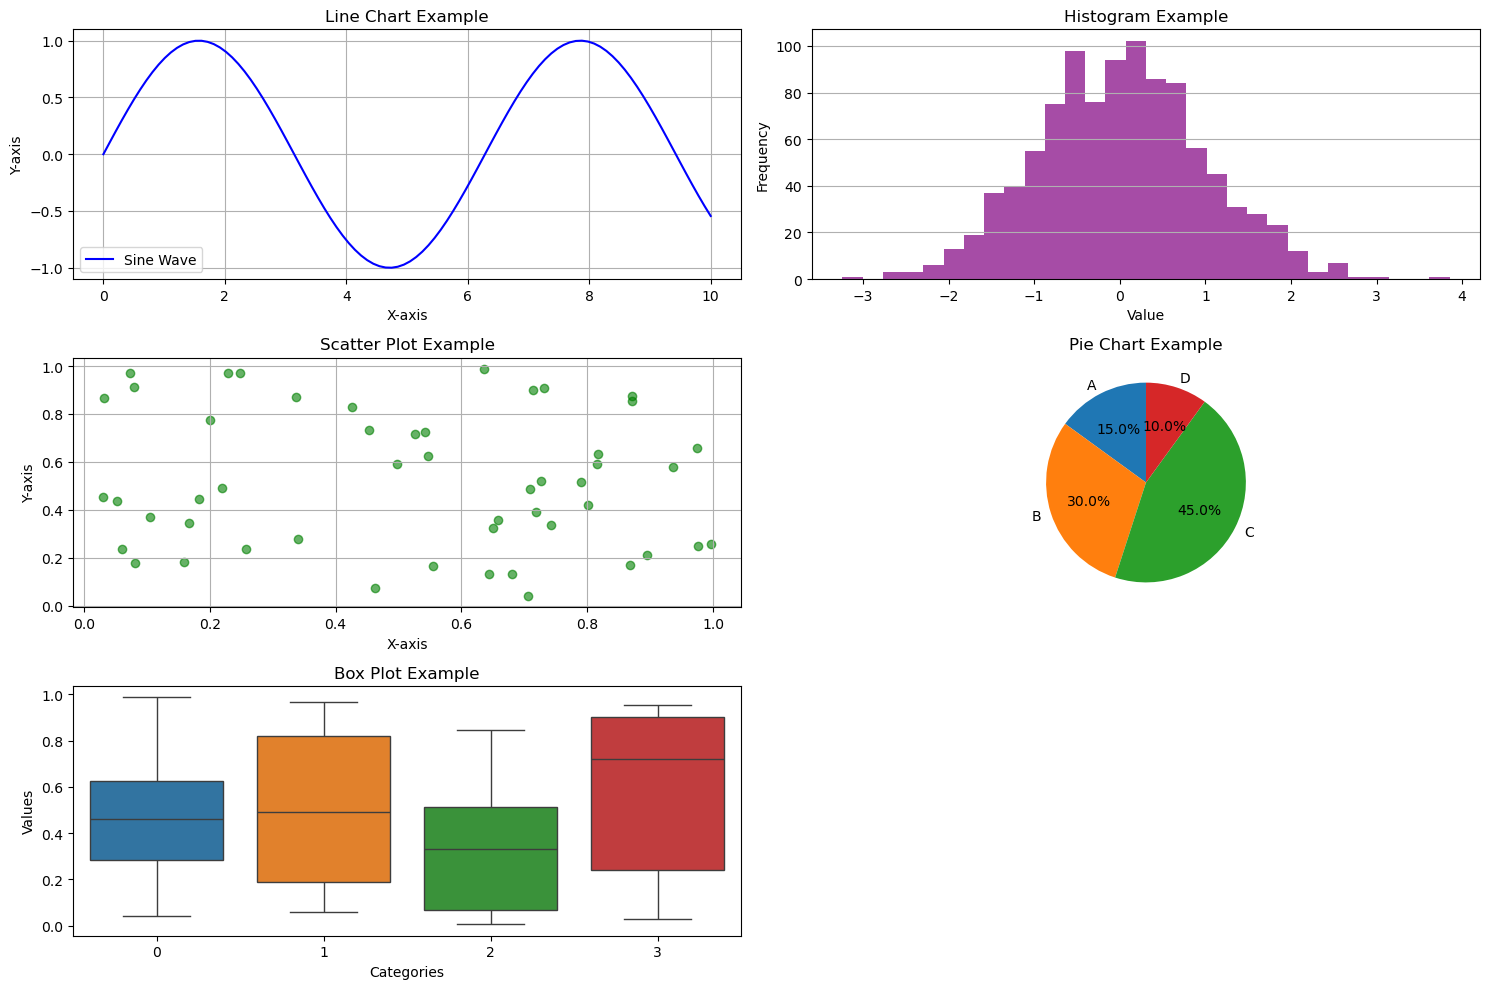

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

np.random.seed(42)

plt.figure(figsize=(15, 10))

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.subplot(3, 2, 1)
plt.plot(x, y, label='Sine Wave', color='blue')
plt.title('Line Chart Example')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid()

data_hist = np.random.randn(1000)

plt.subplot(3, 2, 2)
plt.hist(data_hist, bins=30, color='purple', alpha=0.7)
plt.title('Histogram Example')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(axis='y')

x_scatter = np.random.rand(50)
y_scatter = np.random.rand(50)

plt.subplot(3, 2, 3)
plt.scatter(x_scatter, y_scatter, color='green', alpha=0.6)
plt.title('Scatter Plot Example')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid()

sizes = [15, 30, 45, 10]
labels = ['A', 'B', 'C', 'D']

plt.subplot(3, 2, 4)
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Pie Chart Example')

data_box = np.random.rand(10, 4)

plt.subplot(3, 2, 5)
sns.boxplot(data=data_box)
plt.title('Box Plot Example')
plt.xlabel('Categories')
plt.ylabel('Values')

plt.tight_layout()
plt.show()